In [15]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from astropy.timeseries import LombScargle
import random
import h5py
import pandas as pd
from least_entropy_antialiasing_fixed import get_phases
import os 
from datetime import datetime
from matplotlib.widgets import Button
from IPython.display import clear_output


In [23]:
n = 10
CUSTOM = False
P_INI = 0.1
P_FIN = 10
P_NUM = 10000
db = "singlemode_variable_stars_sample.h5"

Total a procesar: 14 estrellas con status válido
Procesando: 05 (P0=8.2062)


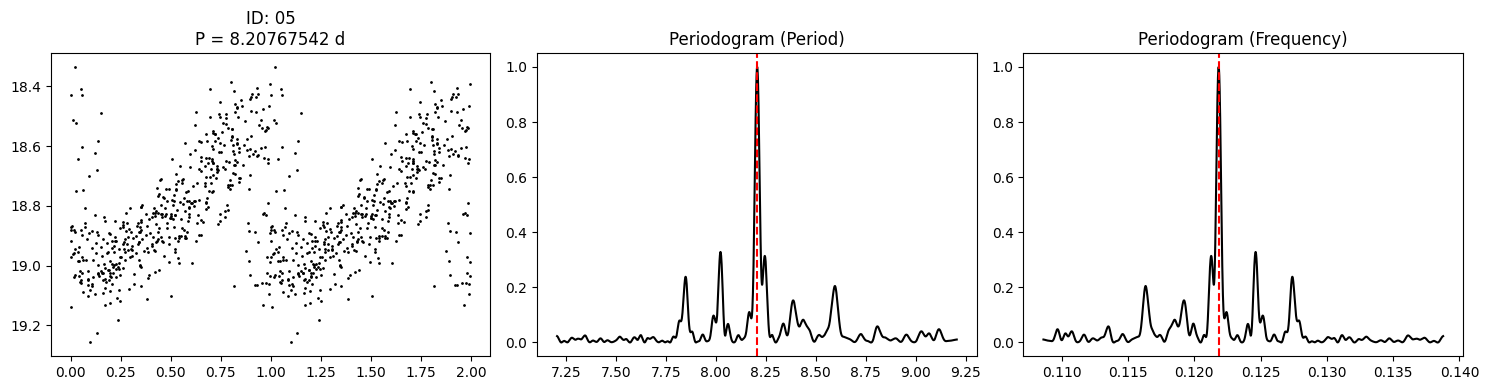

Procesando: 39 (P0=2.1072)


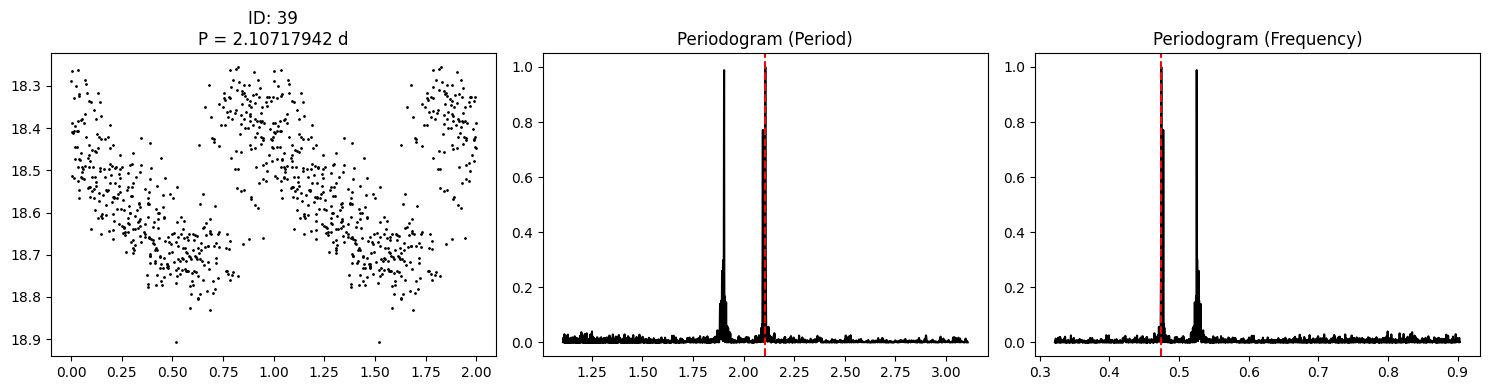

Procesando: 3a (P0=1.6008)


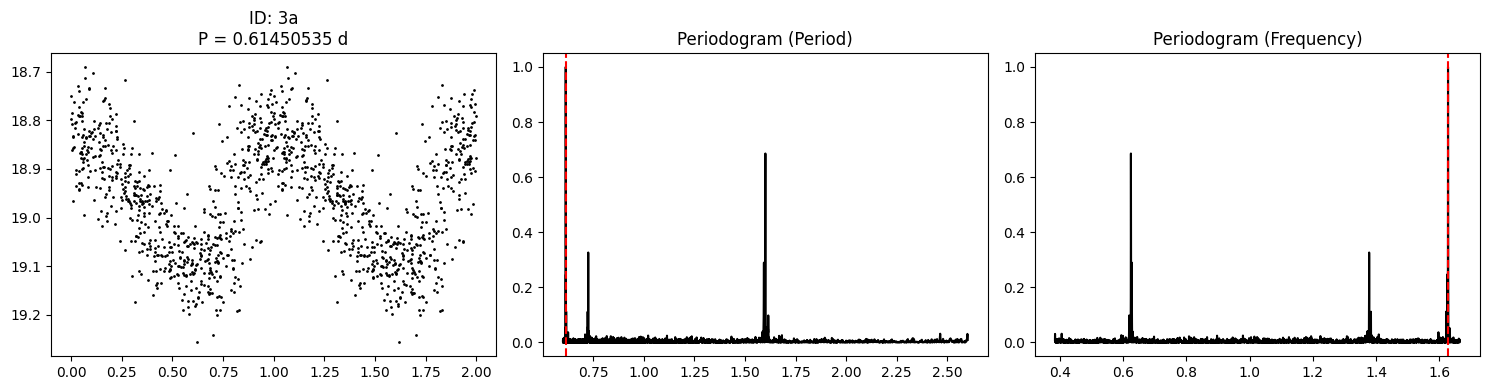

Procesando: 52 (P0=2.4032)


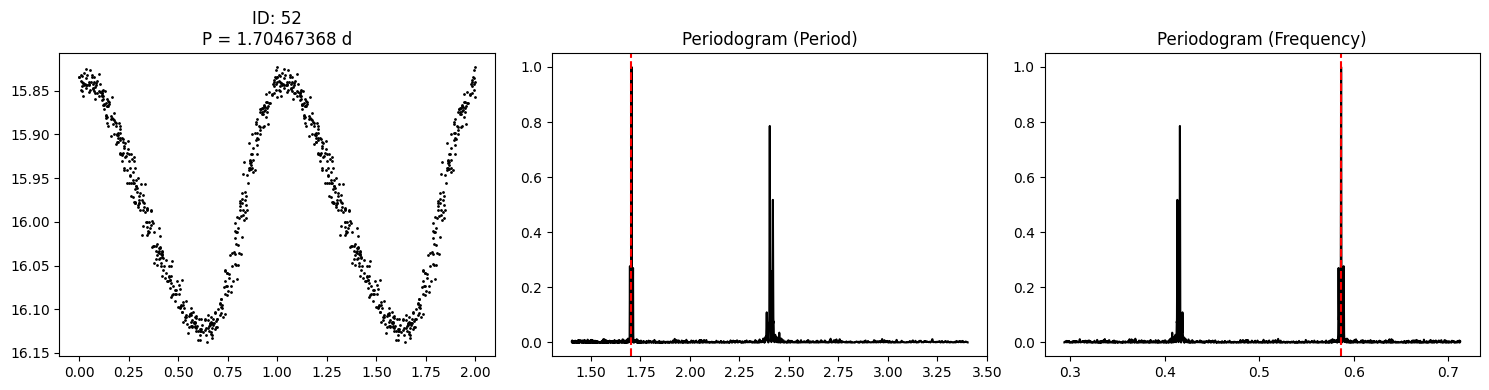

Procesando: 62 (P0=3.6067)


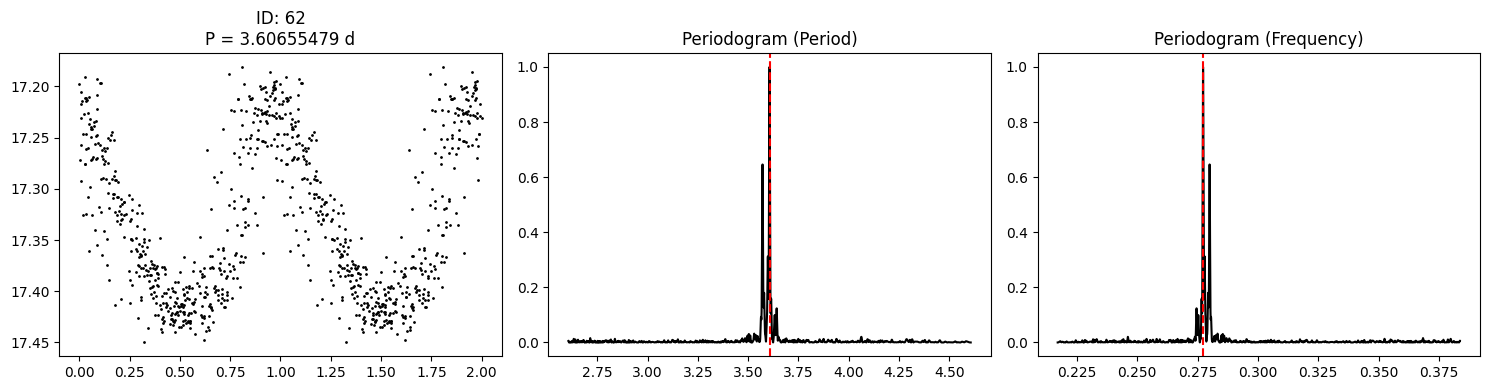

Procesando: 77 (P0=4.5538)


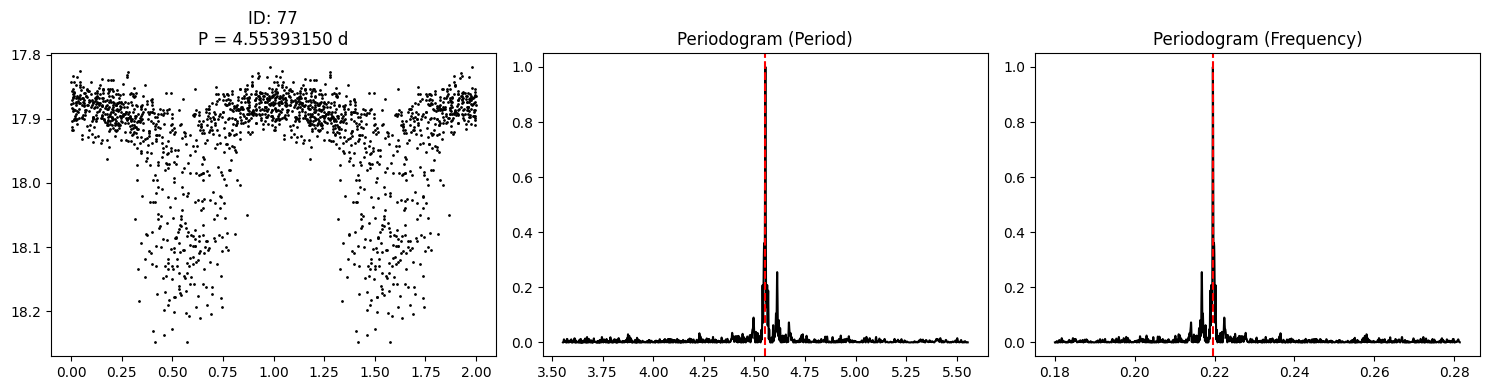

Procesando: 89 (P0=4.0247)


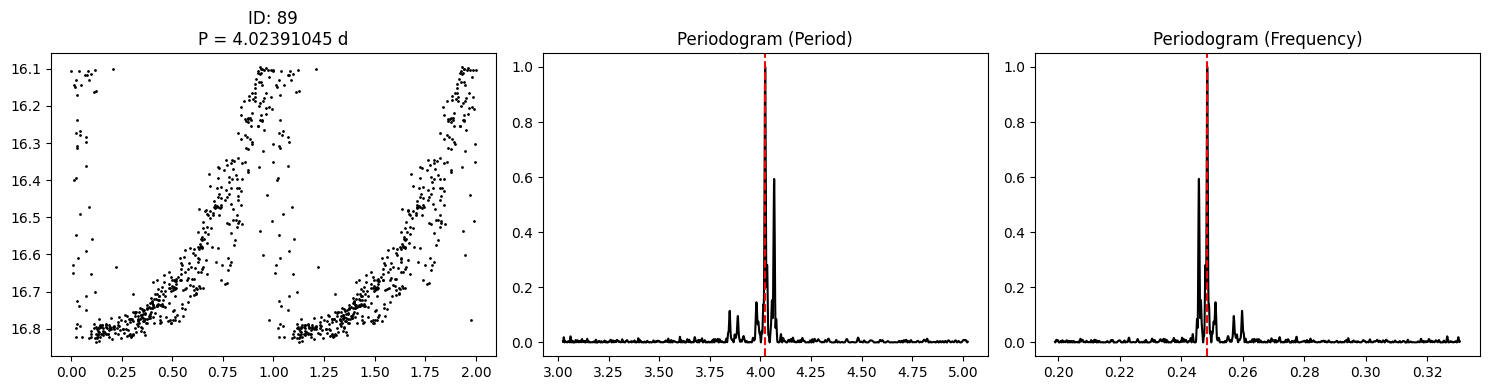

Procesando: 7a (P0=5.6160)


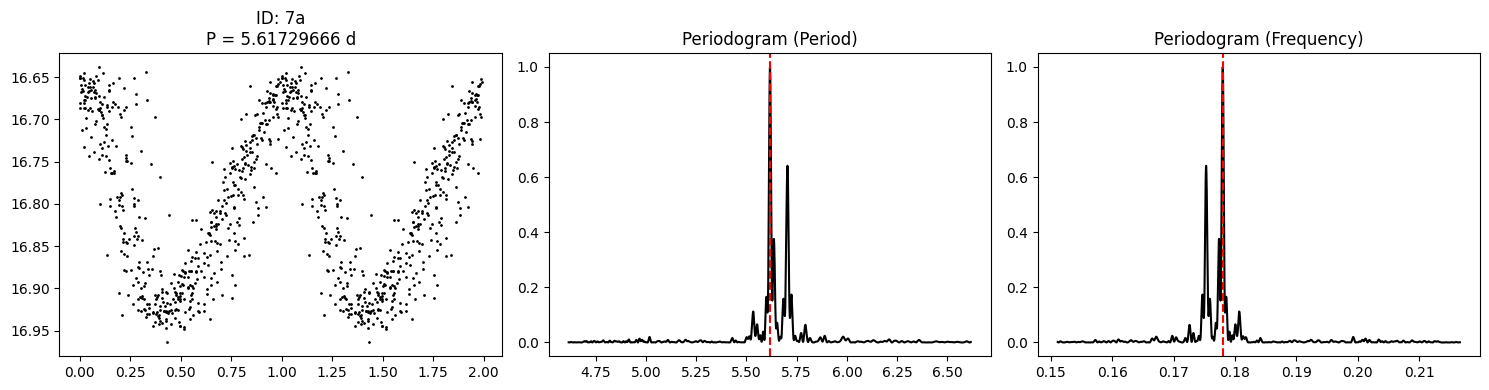

Procesando: 79 (P0=5.9681)


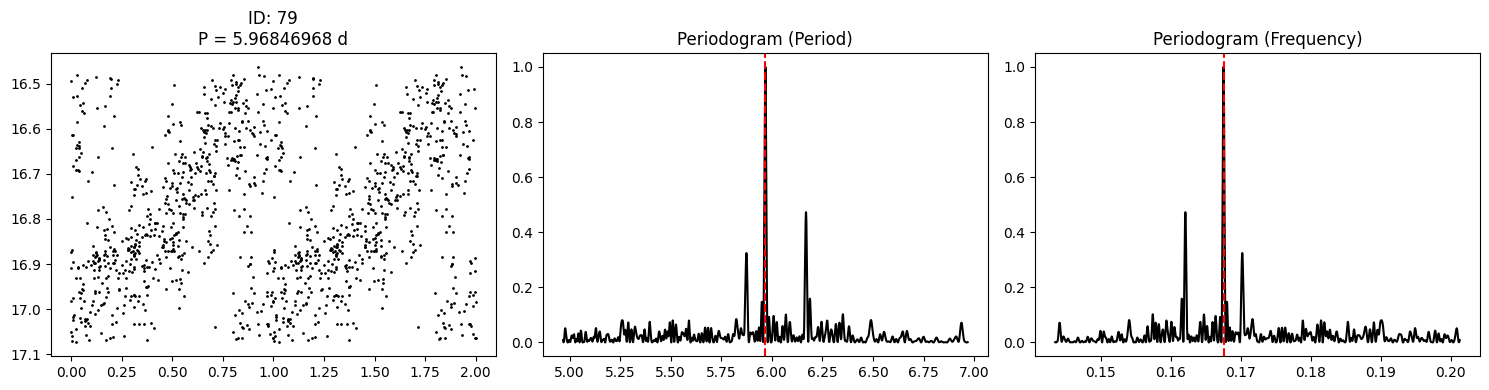

Procesando: 3f (P0=2.4141)


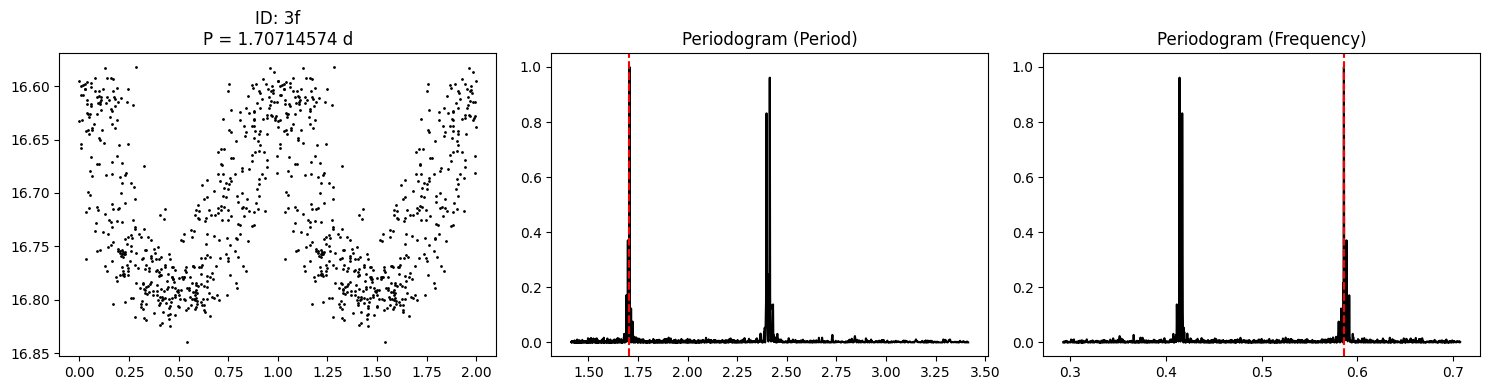

Procesando: 6e (P0=1.8263)


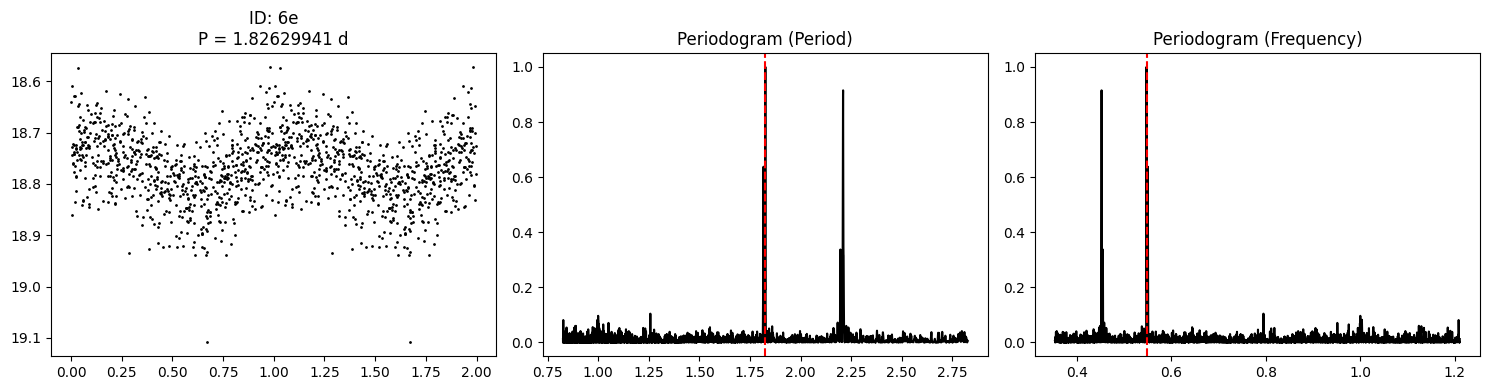

Procesando: 27 (P0=3.6079)


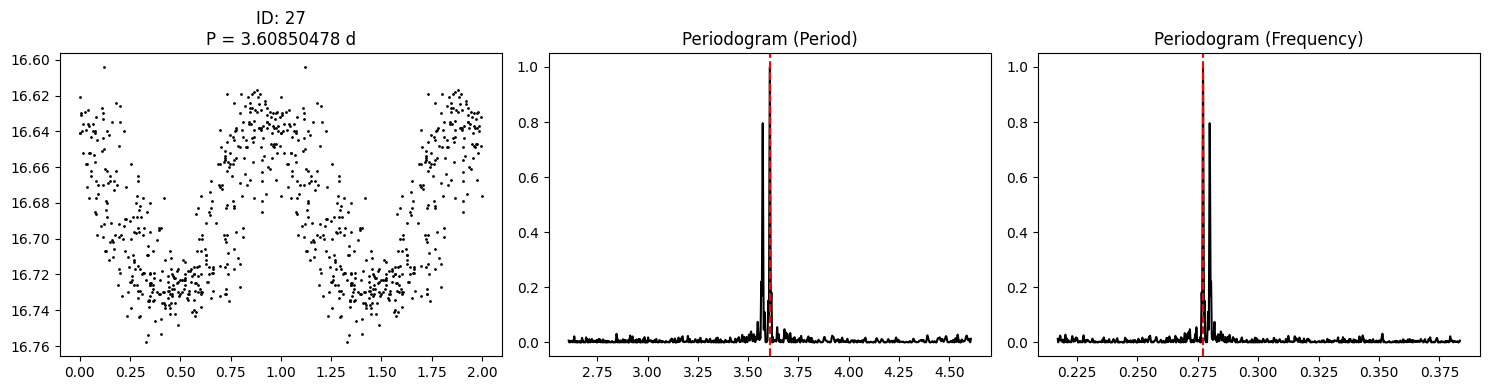

Procesando: 35 (P0=5.6060)


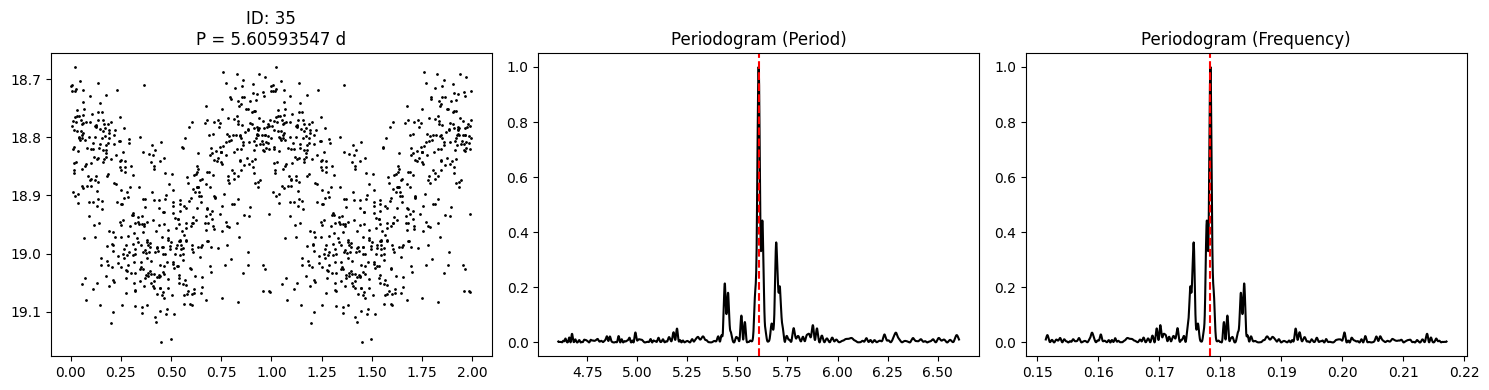

Procesando: 45 (P0=0.9004)


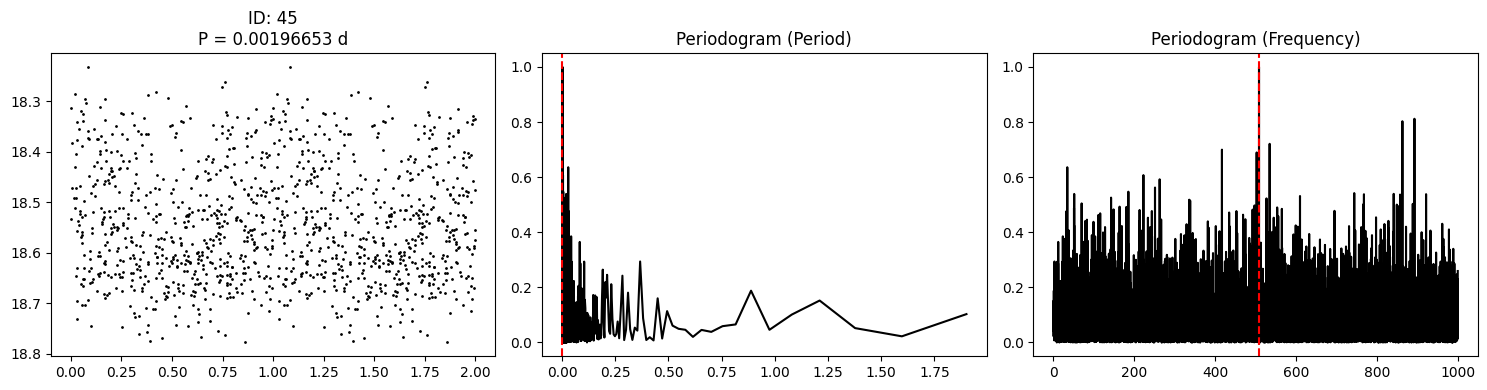

Exportado: resultados_ls/periodos_refinados_20260422_225248.csv (14 estrellas)


In [29]:
found_stars = pd.read_excel("periods.xlsx")

# ventana alrededor del periodo inicial (en días)
DELTA_P = 1.0

# seleccionar solo estrellas con status válido
subset = found_stars[found_stars["notes"].notna()].copy()

subset["id"] = subset["id"].astype(str)

with h5py.File(db, "r") as file:
    star_codes = set(file["/"].keys())

# quedarse solo con IDs que existan en la base
subset = subset[subset["id"].isin(star_codes)]

final_ids = subset["id"].tolist()

print(f"Total a procesar: {len(final_ids)} estrellas con status válido")

# ── Bucle principal ─────────────────────────────────────────────
results = []

with h5py.File(db, "r") as file:

    for _, row in subset.iterrows():

        name = row["id"]
        P0   = row["p_found"]   # ← columna con periodo inicial del Excel

        print(f"Procesando: {name} (P0={P0:.4f})")

        star_raw = file[name][:]

        if len(star_raw) == 0:
            print(f"{name}: dataset vacío → skip")
            continue

        star_data = pd.DataFrame(star_raw)

        if "RHJD" not in star_data or "mag" not in star_data:
            print(f"{name}: columnas faltantes → skip")
            continue

        t = star_data.RHJD.values
        mag = star_data.mag.values

        if len(t) < 3:
            print(f"{name}: muy pocos puntos → skip")
            continue

        # ── ventana personalizada por estrella ─────────────
        P_INI_local = max(0.001, P0 - DELTA_P)
        P_FIN_local = P0 + DELTA_P

        frequency = np.linspace(
            1 / P_FIN_local,
            1 / P_INI_local,
            P_NUM
        )

        power = LombScargle(t, mag).power(
            frequency,
            method="fastchi2"
        )

        if len(power) == 0 or power.max() == 0:
            print(f"{name}: periodograma inválido → skip")
            continue

        power = power / power.max()
        periods = 1 / frequency

        best_frequency = frequency[np.argmax(power)]
        best_period = 1 / best_frequency

        results.append({
            "id": name,
            "period_initial": P0,
            "period_refined": best_period
        })

        # ── fase ─────────────────────────────────────────
        phases1 = get_phases(t, mag, best_period)
        phases2 = phases1 + 1
        phases = np.append(phases1, phases2)
        mag_plot = np.append(mag, mag.copy())

        fig, axs = plt.subplots(1, 3, figsize=(15, 4))

        axs[0].scatter(phases, mag_plot, c="k", s=1)
        axs[0].invert_yaxis()
        axs[0].set_title(
            f"ID: {name}\nP = {best_period:.8f} d"
        )

        axs[1].plot(periods, power, "k-")
        axs[1].axvline(best_period, color="r", linestyle="--")
        axs[1].set_title("Periodogram (Period)")

        axs[2].plot(frequency, power, "k-")
        axs[2].axvline(best_frequency, color="r", linestyle="--")
        axs[2].set_title("Periodogram (Frequency)")

        plt.tight_layout()
        plt.show()


# ── Exportar ─────────────────────────────────────────────
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
os.makedirs("resultados_ls", exist_ok=True)

df_results = pd.DataFrame(results)

output_path = f"resultados_ls/periodos_refinados_{timestamp}.csv"
df_results.to_csv(output_path, index=False)

print(f"Exportado: {output_path} ({len(df_results)} estrellas)")